# Deutsch's Algorithm and Deutsch-Jozsa Algorithm

1. [Problem Statement](#1.-Problem-Statement)
2. [Quantum Solution](#2.-Quantum-Solution)
3. [Deutsch-Jozsa](#3.-Deutsch-Jozsa)
4. [Qiskit Implementation](#4.-Qiskit-Implementation)
5. [Firsthand Experience with ibm_rensselaer](#5.-Firsthand-Experience-with-ibm_rensselaer)

## 1. Problem Statement

Deutsch's algorithm is used to solve the **parity problem**: **Parity** $= f(0) \oplus f(1)$. 
Here, $\oplus$ denotes the XOR operator.

### 1.1 Example

- $f(0) = f(1)$, **Parity** = 0 (even parity, constant function)
- $f(0) \neq f(1)$, **Parity** = 1 (odd parity, balanced function)

### 1.2 Classical Solution
Classically, it takes two steps to see wether $f(0) = f(1)$, because we would have to check what $f(0)$ equals and what $f(1)$ equals. The difference quantumlly is that we can check if $f(0) = f(1)$ in only one step with phase kickback. This function is equivalent to $f(0) \oplus  f(1)$, where if $f(0) = 1$, then $f(1)$ is flipped. If $f$ is $0$, then it's constant. Otherwise, it's balanced. 

## 2. Quantum Solution

### 2.1 Quantum Circuit Explanation
![title](deutschs_images/Deutsch-solution.png)

The circuit starts with:
$$\ket{\psi_0} = \ket{01}$$
After the Hadamard gate is applied, it transforms $\ket{0} \to \ket{+}$ and $\ket{1} \to \ket{-}$. Therefore, $\ket{\psi_0} = \ket{+-}$.<br> 
To simplify, rewrite the plus state and distribute the negative state: $$\ket{\psi_1}=\frac{1}{\sqrt{2}}(\ket{0} \ket{-} + \ket{1}\ket{-})$$

Now, query the oracle $U_f$. 
$$
\ket{\psi_1}=\frac{1}{\sqrt{2}}U_f(\ket{0} \ket{-} + \ket{1}\ket{-})
\\
\ket{\psi_1}=\frac{1}{\sqrt{2}}(U_f\ket{0} \ket{-} + U_f\ket{1}\ket{-})$$

As per definition of phase oracles: $ U_f\ket{x}\ket{-} = (-1)^{f(x)}=\ket{x}\ket{-}$, plug it into the equation:
$$
\ket{\psi_2}=\frac{1}{\sqrt{2}}((-1)^{f(0)}\ket{0}) + (-1)^{f(1)}\ket{1}))
$$

Back to the parity equation:
$$
\\
f(0) = f(1):\\ \pm\frac{1}{\sqrt{2}}(\ket{0}+\ket{1}) \\ \\\pm \ket{+}
\\~\\
f(0) \neq f(1):\\ \pm\frac{1}{\sqrt{2}}(\ket{0}-\ket{1}) \\\pm \ket{-}
$$

Appying last Hadamard gate flips the plus state to zero, and minus state to one:
$$
f(0) = f(1):\\ \\\pm \ket{0}
\\~\\
f(0) \neq f(1):\\ \\\pm \ket{1}

$$

Finally, we measure the first qubit. This matches the parity problem, where:
* If we measure 0, then the function is constant: $f(0) = f(1)$
* If we measure 1, then the function is constant: $f(0) \neq f(1)$


### 2.2 IBM Quantum Composer

[Link](https://quantum.ibm.com/composer/files/new?initial=N4IgdghgtgpiBcIAiMCuAXAzgYwBYHJMACAQQBsBzAewCcBLdXKEAGhAEcJNnEB5ABQCiAOQCKJAMoBZIgCYAdAAYA3AB0wdMNjKoAJjCKqOMMnQBGARnmbsRtWHUUI6A2YhkIWmLoD6qAGZEAJ4sRAAeRMDqRETYEWGhQfYxEUnqAL7q6uw0MBRE7ADasgC69ti5%2BdiFFmXqdLoFNXVgEUWKLbhNHfZdRbX2bh5evgHdJaH9nU0D6rBcqLkzJUQAtAB8sYU96qwg%2Bjj0AA7odFRgCCAg6UA
)
![title](deutschs_images/ibmcomposer.png)

In this quantum circuit, it results in the final state of:
$$
\ket{\psi_2}=\frac{1}{\sqrt{2}}((-1)^{f(0)}\ket{0}) + (-1)^{f(1)}\ket{1}))
$$

Meaning $f(0) \oplus f(1) = 0$ if and only if we measure $\ket{0}$, and $f(0) \oplus f(1) = 1$ if and only if we measure $\ket{1}$. Therefore, we know wether the function $f(x)$ is constant or balanced.

### OPENQASM 2.0 Code

In [ ]:
'''

OPENQASM 2.0;
include "qelib1.inc";

gate balanced_uf y, x {
  cx x, y;
  x y;
}

qreg q[2];
creg c[1];
id q[1];
x q[0];
h q[0];
h q[1];
balanced_uf q[0], q[1];
h q[1];
measure q[1] -> c[0];

'''

## 3. Deutsch Jozsa

### 3.1 Parity Problem

Deutsch-Jozsa algorithm is used to solve the **parity problem**.
However, the function takes in n-bit binary values, and outputs a 0 or 1 for each input.

- $f:\{0,1\}^n = f:\{0,1\}^n, Parity = 0$ (even parity, constant function)
- $f:\{0,1\}^n \neq f:\{0,1\}^n, Parity = 0$ (even parity, constant function)

### 3.2 Quantum Circuit

The circuit is similar to Deutsch's algorithm, except at $\ket{\psi_0}$ it starts with $n$ qubits initialized to $\ket{0}$ and the final qubit is initialized to $\ket{1}$.

![title](deutschs_images/jozsa.png)

At state $\ket{\psi_1}$, a Hadamard is applied to all qubits, resulting in:
$$\frac{1}{\sqrt{2^{n+1}}} \sum_{x=0}^{2^n-1}|x\rangle(|0\rangle-|1\rangle)$$
Where $x$ runs over all $n$-bit strings.

Then, we apply the oracle, which maps $\ket{x}\ket{y}$ to $\ket{x}\ket{y \oplus f(x)}$. Because $f(x)$ can be either 0 or 1, we can simplify the $f(x)$ to:
$$\frac{1}{\sqrt{2^{n+1}}} \sum_{x=0}^{2^n-1}(-1)^{f(x)}|x\rangle(|0\rangle-|1\rangle)$$
Then, we can drop the last qubit, removing a $\frac{1}{\sqrt{2}}$  and $(\ket{0} - \ket{1})$:
$$\ket{\psi_2} = \frac{1}{\sqrt{2^n}} \sum_{x=0}^{2^n-1}(-1)^{f(x)}|x\rangle$$

After the Hadamard is applied at $\ket{\psi_3}$, the final state is:
$$\left|\frac{1}{2^n} \sum_{x=0}^{2^n-1}(-1)^{f(x)}\right|^2$$

Meaning that the final measurement will be $\ket{0}^{\bigotimes{n}}$ (all zeroes) if $f(x)$ is constant and some other state if $f(x)$ is balanced.

## 4. Qiskit Implementation

### Imports

In [1]:
%pip install qiskit
%pip install qiskit_ibm_runtime
%pip install qiskit_aer
%pip install numpy


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import qiskit
print(qiskit.version.get_version_info())

1.0.2


### 4.1 Circuit Construction

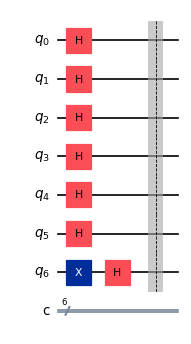

In [3]:
from qiskit import QuantumCircuit

# Preprocessing
# Select a secret bit string
n = '110101'

# Number of qubits to represent n
num_qubits = num_bits = len(n)

# Create a circuit with num_qubits + output qubit, and num_bits
qc = QuantumCircuit(num_qubits + 1, num_qubits)

# Flip output qubit
qc.x(num_qubits)

# Apply Hadamards to all other qubits
qc.h(range(0, num_qubits + 1))

qc.barrier()

qc.draw(output="mpl", scale=0.6)

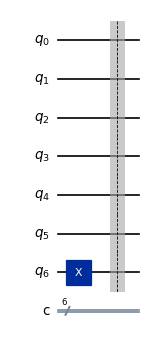

In [4]:
# 1-constant oracle
constant_1 = QuantumCircuit(num_qubits + 1, num_qubits)
constant_1.x(num_qubits) # Flip the answer qubit so oracle returns |1>

constant_1.barrier()
constant_1.draw(output="mpl", scale=0.6)

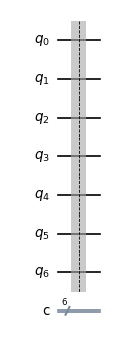

In [5]:
# 0-constant oracle
constant_0 = QuantumCircuit(num_qubits + 1, num_qubits)
pass # Keep the answer qubit the same so oracle returns |0>

constant_0.barrier()
constant_0.draw(output="mpl", scale=0.6)

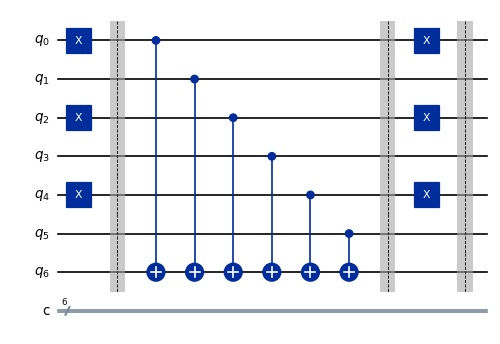

In [6]:
# Balanced oracle
balanced = QuantumCircuit(num_qubits + 1, num_qubits)

# Apply X gate to half of the qubits (50% return 0 and 50% return 1)
def apply_X_gates():
    for i in range(num_qubits):
        if i%2 == 0:
            balanced.x(i)

apply_X_gates()

balanced.barrier()

for i in range(num_qubits):
    balanced.cx(i,num_qubits) # Apply CX gate on all qubits on the answer qubit

balanced.barrier()

apply_X_gates() # Undo the X gates

balanced.barrier()
balanced.draw(output="mpl", scale=0.6)

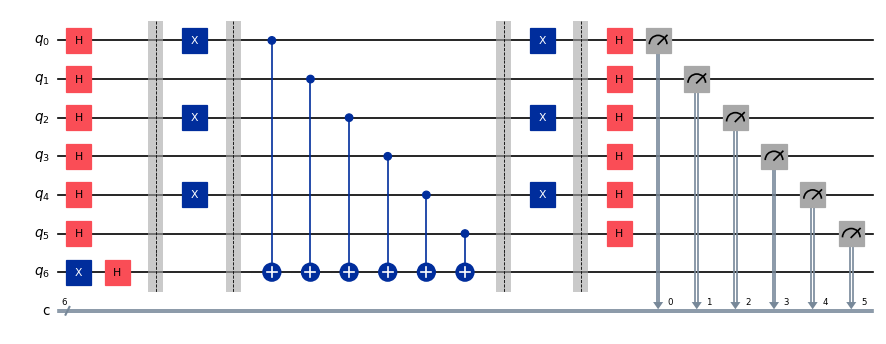

In [7]:
# Add the oracle to the circuit (input is balanced)
qc = qc.compose(balanced)

# Apply Hadamards to all qubits
qc.h(range(0, num_qubits))
    
for i in range(num_qubits):
    qc.measure(i, i)
    
qc.draw(output="mpl", scale=0.6)

### 4.2 Running on a Simulator

The counts are: {'111111': 4096}


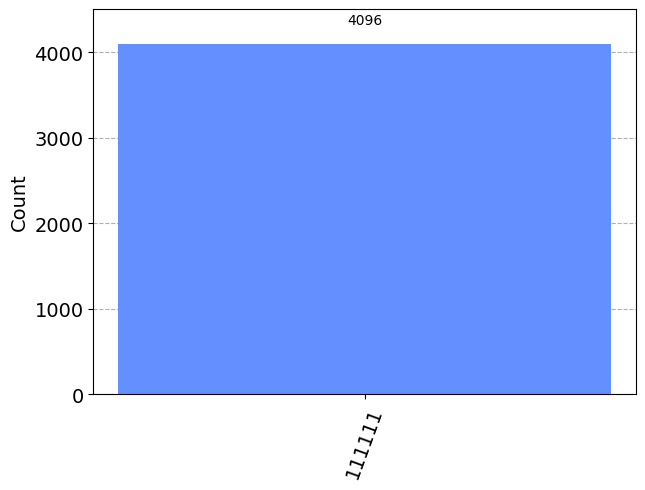

In [8]:
# Running on Simulator
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram

sampler = StatevectorSampler()

sim_qc = qc

# Run using sampler
result = sampler.run([sim_qc], shots=4096).result()

# Get counts for the classical register "c"
counts = result[0].data.c.get_counts()
print(f"The counts are: {counts}")

plot_histogram(counts)

## 5. Firsthand Experience with ibm_rensselaer

As usual, we initialize the ``QiskitRuntimeService`` to interact with IBM Quantum resources.

If you have not already, use the following snippet to log in and save your IBM Quantum account credentials for future use. Replace the ``token`` with your own API token available when you log in at https://quantum.ibm.com/.

In [9]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
     channel="ibm_quantum",
     token="2b448a87edc3477cee73e4f8c0349e3911e8c494fd4138c0a093c4b1c4d980b8e05b1291399c4df9ae9184b251214704ba5896b143c480441930f2cfbdbb9e8c",
     set_as_default=True,
     # Use 'overwrite=True' if you're updating your token.
     overwrite=True,
)

In [10]:
service = QiskitRuntimeService()

# Should be "ibm_rensselaer". If not and you have access to the computer, comment this out and set the backend manually.
# backend = service.least_busy(operational=True, simulator=False)
# print(backend.name)

backend = service.backend("ibm_rensselaer")
print(backend.name)

status = backend.status()
print(f"Backend: {backend.name}")
print(f"Status: {status.status_msg}")
print(f"Pending Jobs: {status.pending_jobs}")
print(f"Operational: {status.operational}")



ibm_rensselaer
Backend: ibm_rensselaer
Status: active
Pending Jobs: 0
Operational: True


We use a preset pass manager with minimal options to transpile our current Deutch-Jozsa circuit into the basis gates of the backend we are using, ``ibm_rensselaer``. \
Then, we initialize a Sampler with the backend to execute the circuit on ``ibm_rensselaer``. This should take a couple of seconds.


In [11]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(target=backend.target, optimization_level=1)

isa_circuit = pm.run(qc)

### Deutsch’s Algorithm Execution on Quantum Hardware (SamplerV2)

In [1]:
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.visualization import plot_histogram

# (Assume your Deutsch circuit is defined and stored in `qc`)
# Transpile for the backend
pm = generate_preset_pass_manager(target=backend.target, optimization_level=1)
isa_circuit = pm.run(qc)

# Initialize the Sampler
sampler = Sampler(backend=backend)

# Run the circuit with SamplerV2
job = sampler.run([isa_circuit], shots=4096)
job_result = job.result()

# Extract raw counts (not quasi-dist)
counts = job_result[0].data.c.get_counts()

# Optional filtering for visualization (removes noise below 1% of total shots)
threshold = int(0.01 * 4096)
filtered_counts = {k: v for k, v in counts.items() if v >= threshold}

# Show result
print(f"Filtered counts: {filtered_counts}")
plot_histogram(filtered_counts)


NameError: name 'job' is not defined

#### Results